In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv


# Student Performance Analysis & Grade Prediction

## Objective

This project analyzes the Student Performance Factors dataset using Exploratory Data Analysis (EDA) and Machine Learning to uncover patterns, identify important factors affecting exam scores, and build predictive models.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis
6. Correlation Analysis
7. Feature Engineering
8. Machine Learning
9. Model Evaluation
10. Conclusion

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [10]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv


# Load Dataset

In [15]:
df = pd.read_csv("/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv")

In [16]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [17]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10
648,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,4,10,11,11


In [18]:
df.sample(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
129,GP,M,16,U,GT3,T,2,3,other,other,...,3,2,3,2,2,1,4,13,12,13
357,GP,F,18,U,GT3,T,4,3,other,other,...,4,3,4,1,1,5,2,14,15,17
146,GP,M,16,U,LE3,T,1,1,services,other,...,4,4,4,1,3,5,0,10,10,10
67,GP,F,16,U,GT3,T,3,1,services,other,...,4,3,3,1,2,5,0,10,9,10
386,GP,F,17,R,GT3,T,2,4,at_home,other,...,4,4,3,1,1,5,0,15,15,15


# Dataset Information

In [19]:
print("Shape of Dataset :", df.shape)

Shape of Dataset : (649, 33)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [21]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [22]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

# Statistical Summary

In [23]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


# Check Missing Values

In [24]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [25]:
(df.isnull().sum()/len(df))*100

school        0.0
sex           0.0
age           0.0
address       0.0
famsize       0.0
Pstatus       0.0
Medu          0.0
Fedu          0.0
Mjob          0.0
Fjob          0.0
reason        0.0
guardian      0.0
traveltime    0.0
studytime     0.0
failures      0.0
schoolsup     0.0
famsup        0.0
paid          0.0
activities    0.0
nursery       0.0
higher        0.0
internet      0.0
romantic      0.0
famrel        0.0
freetime      0.0
goout         0.0
Dalc          0.0
Walc          0.0
health        0.0
absences      0.0
G1            0.0
G2            0.0
G3            0.0
dtype: float64

# Check Duplicate Values

In [26]:
df.duplicated().sum()

np.int64(0)

In [44]:
df = df.drop_duplicates()

# Check Unique Values

In [45]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()} unique values")

school : 2 unique values
sex : 2 unique values
age : 8 unique values
address : 2 unique values
famsize : 2 unique values
Pstatus : 2 unique values
Medu : 5 unique values
Fedu : 5 unique values
Mjob : 5 unique values
Fjob : 5 unique values
reason : 4 unique values
guardian : 3 unique values
traveltime : 4 unique values
studytime : 4 unique values
failures : 4 unique values
schoolsup : 2 unique values
famsup : 2 unique values
paid : 2 unique values
activities : 2 unique values
nursery : 2 unique values
higher : 2 unique values
internet : 2 unique values
romantic : 2 unique values
famrel : 5 unique values
freetime : 5 unique values
goout : 5 unique values
Dalc : 5 unique values
Walc : 5 unique values
health : 5 unique values
absences : 24 unique values
G1 : 17 unique values
G2 : 16 unique values
G3 : 17 unique values


# Separate Numerical & Categorical Columns

In [46]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

Numerical Columns
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

Categorical Columns
Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


# Check Data Distribution

In [47]:
df.describe(include='all')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649,649,649.000000,649,649,649,649.000000,649.000000,649,649,...,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,423,383,NaN,452,457,569,NaN,NaN,258,367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.744222,NaN,NaN,NaN,2.514638,2.306626,NaN,NaN,...,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,NaN,NaN,1.218138,NaN,NaN,NaN,1.134552,1.099931,NaN,NaN,...,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000


# Data Cleaning

In [69]:

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [74]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Univariate Analysis (Single Variable Analysis)
# Distribution of Exam Score

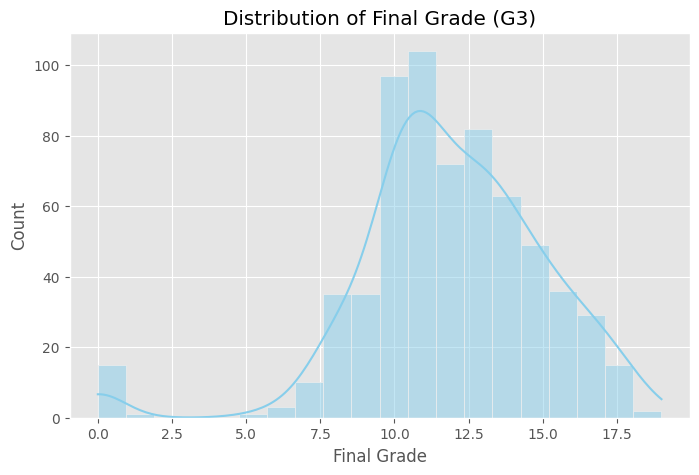

In [77]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.show()

### Insight

- Most students scored between 10 and 15.
- Very few students scored below 5.
- The grades are approximately normally distributed.

# Gender Distribution

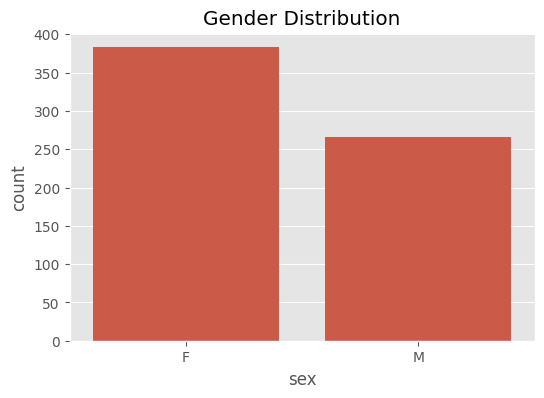

In [78]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

# Age Distribution

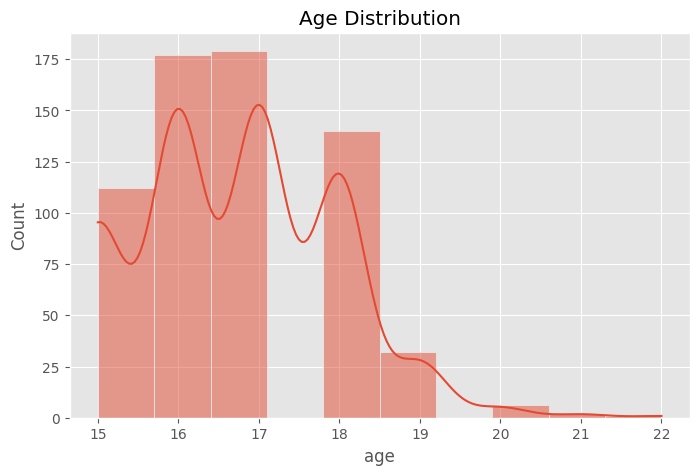

In [79]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

# Study Time

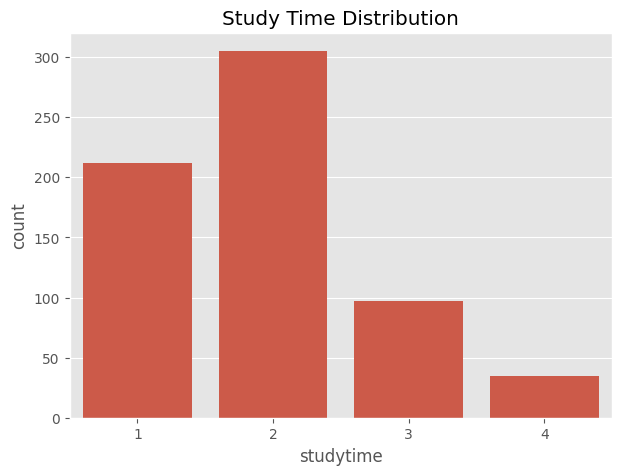

In [80]:
plt.figure(figsize=(7,5))
sns.countplot(x='studytime', data=df)
plt.title("Study Time Distribution")
plt.show()

# Internet Access

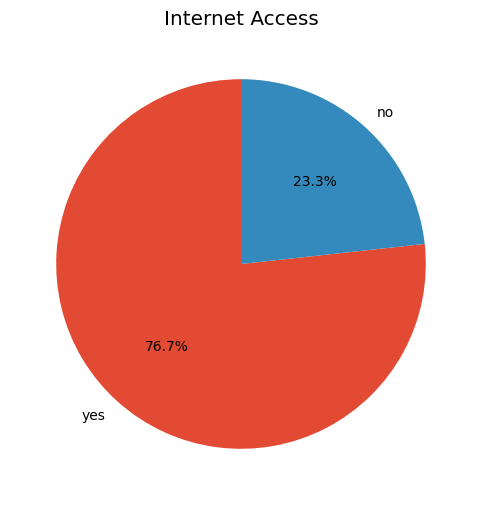

In [81]:
internet = df['internet'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(internet,
        labels=internet.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Internet Access")
plt.show()

# Box Plot of Final Grade

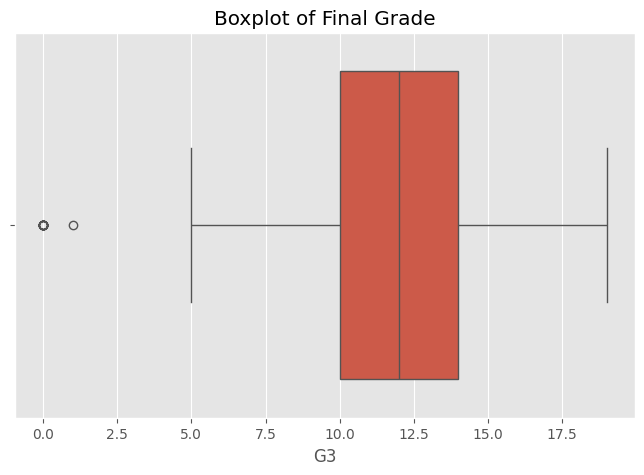

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['G3'])
plt.title("Boxplot of Final Grade")
plt.show()

# Absence Distribution

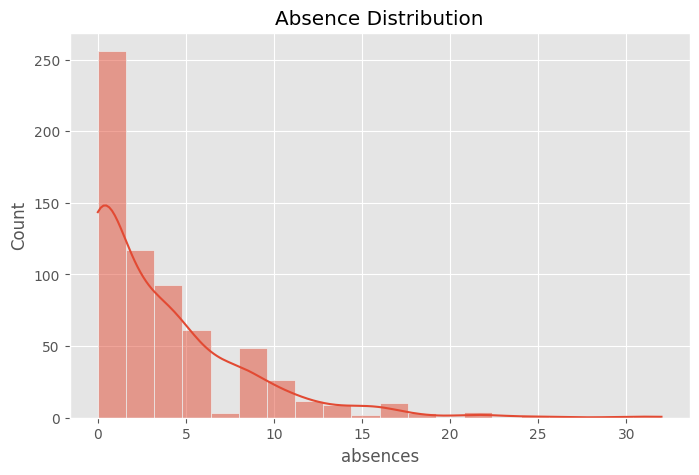

In [83]:
plt.figure(figsize=(8,5))
sns.histplot(df['absences'], bins=20, kde=True)
plt.title("Absence Distribution")
plt.show()

# Failures Distribution

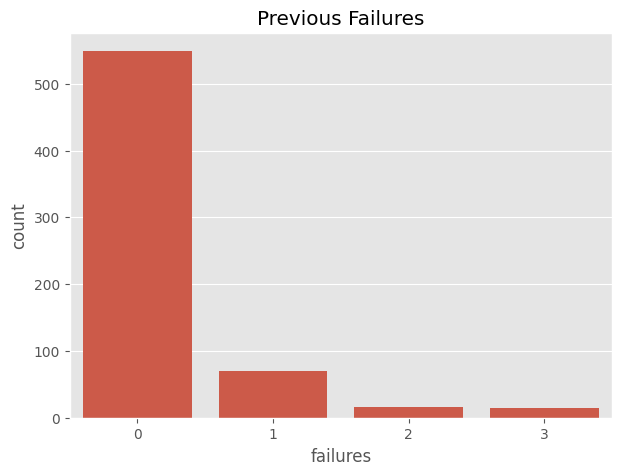

In [84]:
plt.figure(figsize=(7,5))
sns.countplot(x='failures', data=df)
plt.title("Previous Failures")
plt.show()

# Parent Education

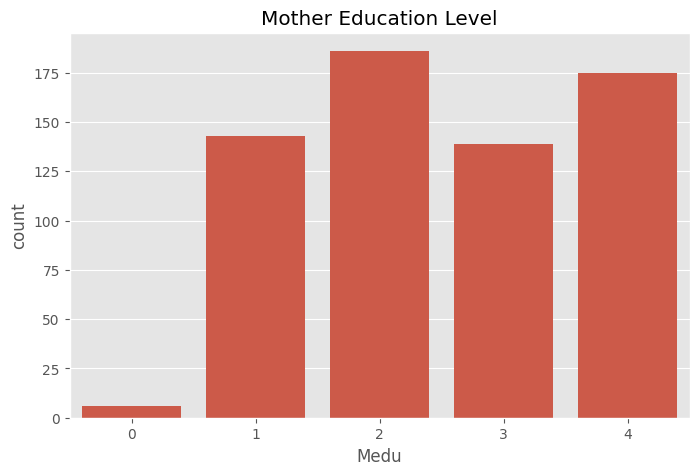

In [85]:
plt.figure(figsize=(8,5))
sns.countplot(x='Medu', data=df)
plt.title("Mother Education Level")
plt.show()

# Health Distribution

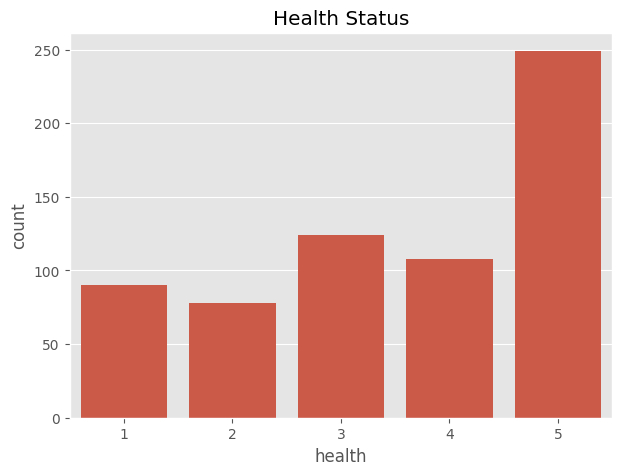

In [86]:
plt.figure(figsize=(7,5))
sns.countplot(x='health', data=df)
plt.title("Health Status")
plt.show()

 # Bivariate Analysis (Study Time vs Final Grade)

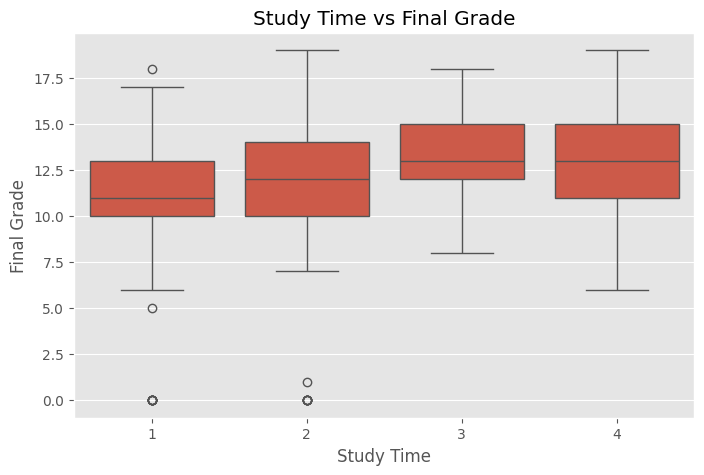

In [87]:
plt.figure(figsize=(8,5))
sns.boxplot(x='studytime', y='G3', data=df)

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.show()

### Insight

- Students with higher study time generally achieve better final grades.
- Increasing study time has a positive impact on academic performance.

# Failures vs Final Grade

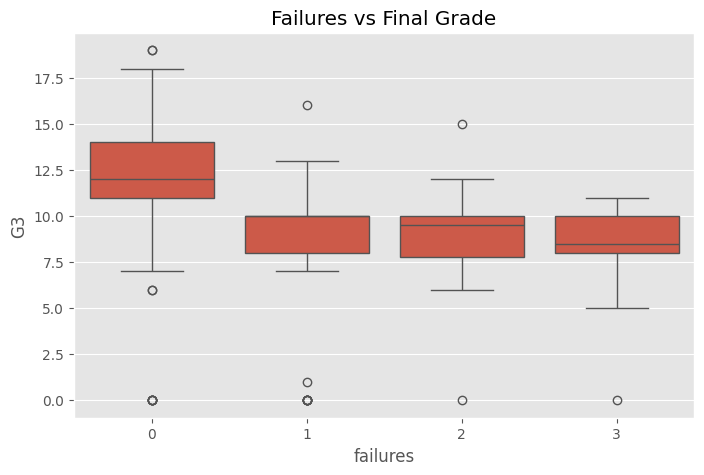

In [88]:
plt.figure(figsize=(8,5))
sns.boxplot(x='failures', y='G3', data=df)

plt.title("Failures vs Final Grade")
plt.show()

### Insight

- Students with previous failures tend to score lower in the final exam.

# Internet Access vs Final Grade

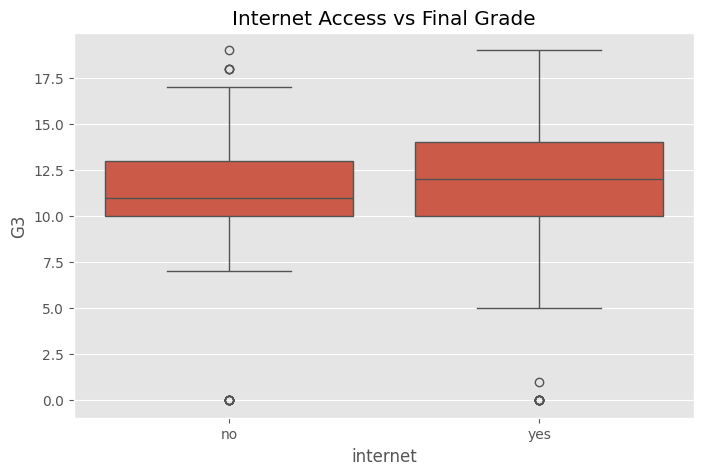

In [89]:
plt.figure(figsize=(8,5))
sns.boxplot(x='internet', y='G3', data=df)

plt.title("Internet Access vs Final Grade")
plt.show()

# Gender vs Final Grade

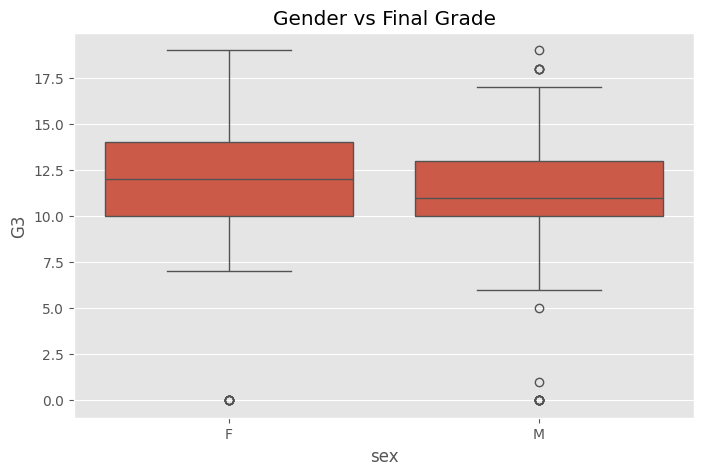

In [90]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sex', y='G3', data=df)

plt.title("Gender vs Final Grade")
plt.show()

# Mother's Education vs Final Grade

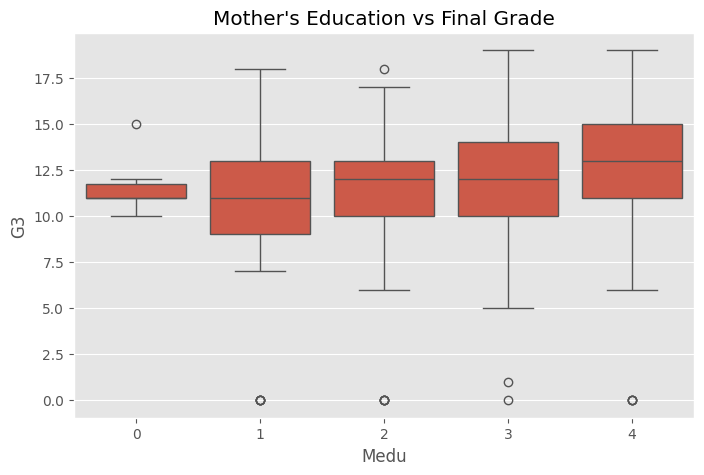

In [91]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Medu', y='G3', data=df)

plt.title("Mother's Education vs Final Grade")
plt.show()

# Father's Education vs Final Grade

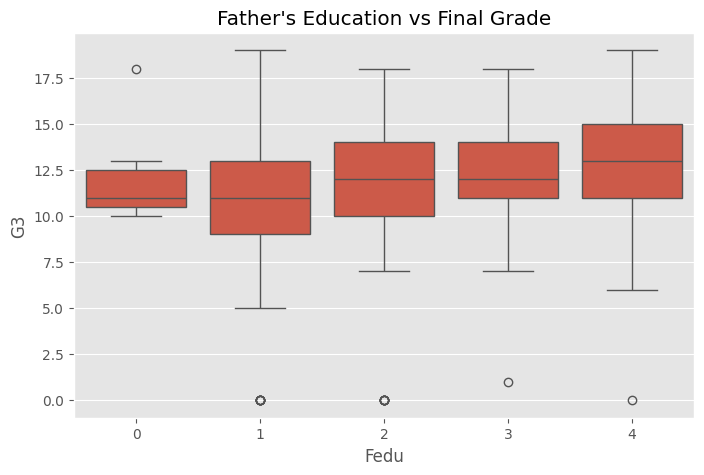

In [92]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Fedu', y='G3', data=df)

plt.title("Father's Education vs Final Grade")
plt.show()

# Absences vs Final Grade

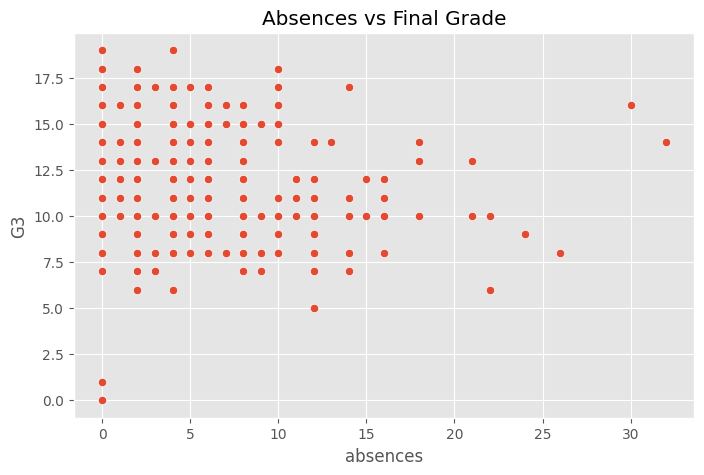

In [93]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='absences', y='G3', data=df)

plt.title("Absences vs Final Grade")
plt.show()

### Insight

- Students with more absences generally have lower final grades.

# Previous Grades vs Final Grade

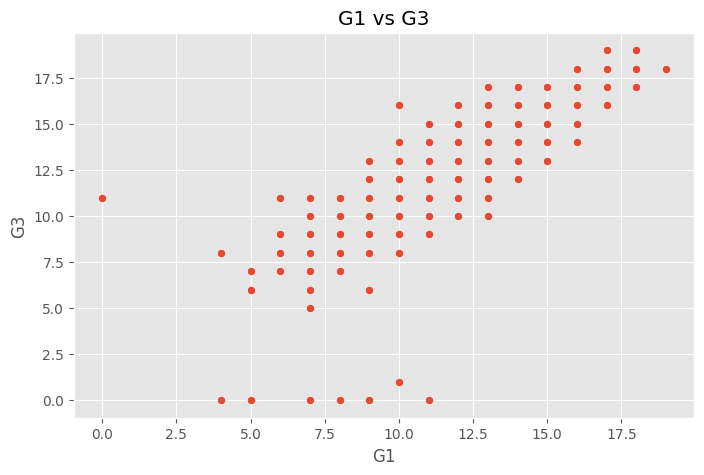

In [94]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='G1', y='G3', data=df)

plt.title("G1 vs G3")
plt.show()

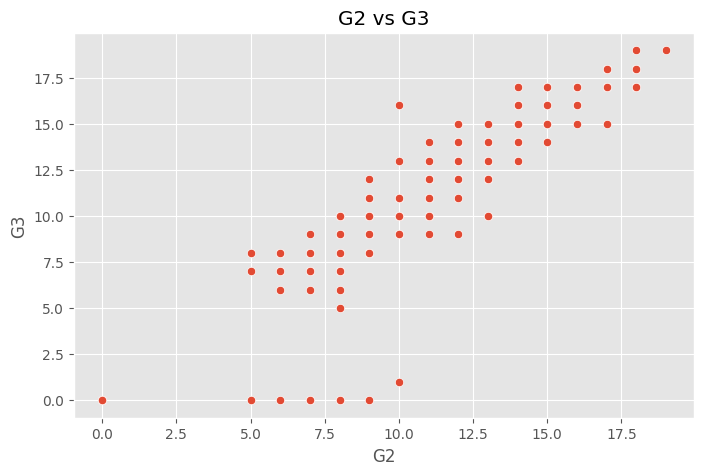

In [95]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='G2', y='G3', data=df)

plt.title("G2 vs G3")
plt.show()

### Insight

- Previous grades (G1 and G2) have a strong positive relationship with the final grade (G3).

# Correlation Heatmap

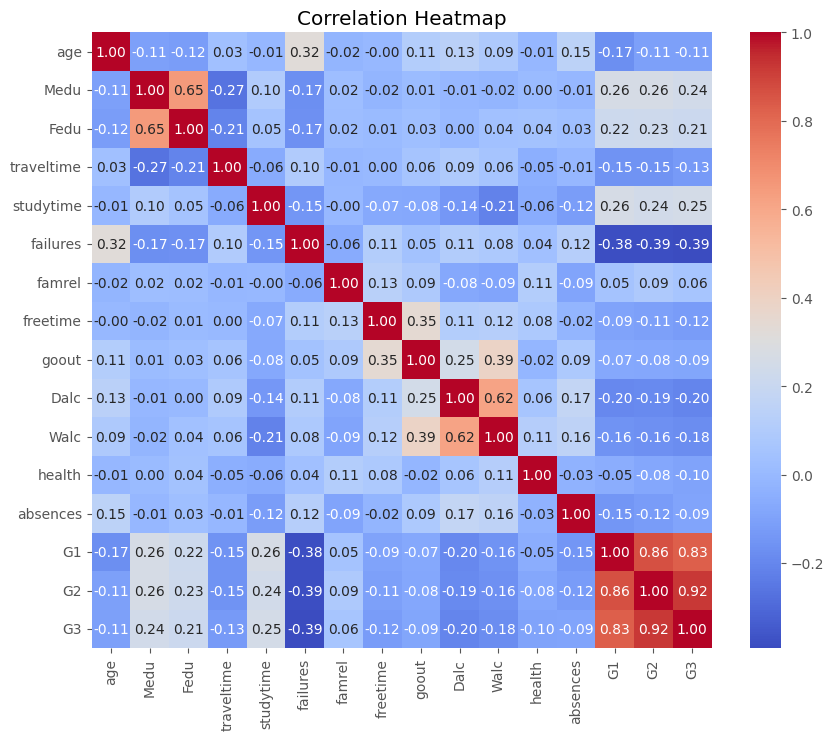

In [96]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Pair Plot

In [98]:
corr = numeric_df.corr()

corr["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

# Correlation with Final Grade

In [99]:
corr = numeric_df.corr()

corr["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

### Key Influencing Factors

The correlation analysis shows that:

- G2 has the strongest positive correlation with G3.
- G1 also strongly influences G3.
- Study time has a moderate positive effect.
- Failures have a negative correlation with G3.
- Absences slightly reduce student performance.

# Encode Categorical Columns

In [100]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,4,0,11,11
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,2,9,11,11
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,6,12,13,12
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,0,14,14,14
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,0,11,13,13


# Define Features & Target

In [108]:
X = df_ml.drop("G3", axis=1)
y = df_ml["G3"]

# Train-Test Split

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(519, 32)
(130, 32)


# Linear Regression

In [113]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# Decision Tree

In [134]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# Random Forest

In [135]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Model Evaluation

In [136]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate(name, y_true, y_pred):
    print("="*50)
    print(name)

    print("MAE :", mean_absolute_error(y_true, y_pred))

    print("MSE :", mean_squared_error(y_true, y_pred))

    print("RMSE :", np.sqrt(mean_squared_error(y_true, y_pred)))

    print("R2 Score :", r2_score(y_true, y_pred))

evaluate("Linear Regression", y_test, lr_pred)

evaluate("Decision Tree", y_test, dt_pred)

evaluate("Random Forest", y_test, rf_pred)

Linear Regression
MAE : 0.7554213592640453
MSE : 1.437093704240998
RMSE : 1.1987884318097994
R2 Score : 0.8526317103852281
Decision Tree
MAE : 0.8615384615384616
MSE : 3.6923076923076925
RMSE : 1.9215378456610457
R2 Score : 0.6213684133880246
Random Forest
MAE : 0.7456153846153847
MSE : 1.548326923076923
RMSE : 1.2443178545198663
R2 Score : 0.841225182641198


# Compare Models

In [137]:
results = pd.DataFrame({
    "Model":["Linear Regression","Decision Tree","Random Forest"],
    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.852632
1,Decision Tree,0.621368
2,Random Forest,0.841225


# Plot Model Comparison

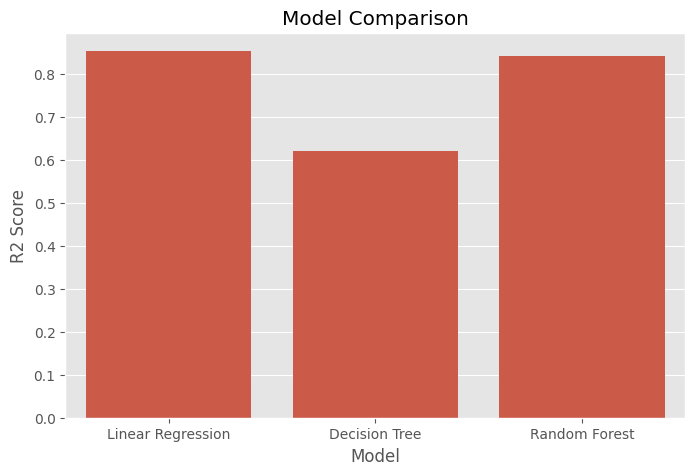

In [138]:
plt.figure(figsize=(8,5))

sns.barplot(data=results, x="Model", y="R2 Score")

plt.title("Model Comparison")

plt.show()

# Feature Importance

In [139]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
31,G2,0.826141
29,absences,0.036847
30,G1,0.021396
2,age,0.008565
26,Dalc,0.008064
6,Medu,0.007669
24,freetime,0.007055
0,school,0.006903
23,famrel,0.006438
25,goout,0.006050


# Feature Importance Graph

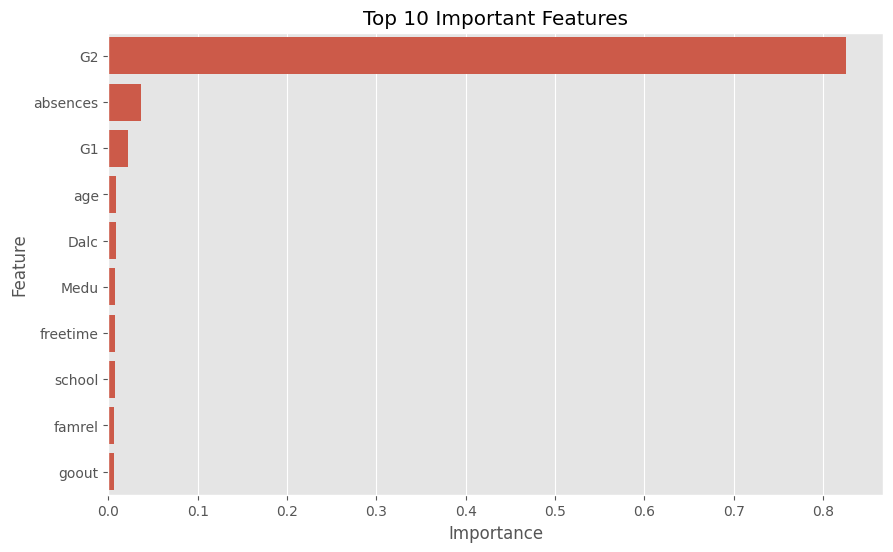

In [140]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Actual vs Predicted

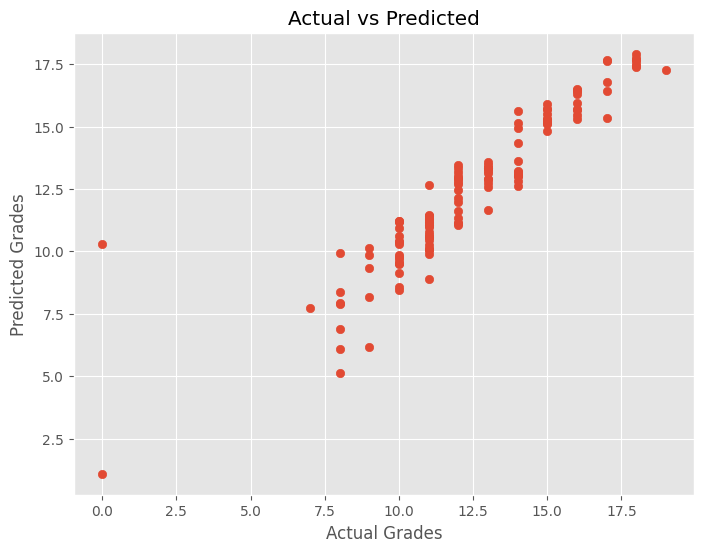

In [141]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Grades")

plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted")

plt.show()

# Final Business Insights 
- Students with higher study time generally achieve better final grades.
- Previous grades (G1 and G2) are the strongest predictors of final performance.
- Students with more failures tend to score lower.
- Higher parental education is associated with better academic performance.
- Students with fewer absences generally achieve higher grades.
- Internet access alone has limited impact on performance.
- Random Forest performed better than Linear Regression and Decision Tree for grade prediction.

# Conclusion
This project explored the Student Performance dataset using Exploratory Data Analysis (EDA) and Machine Learning.

## Key Findings

- Previous grades (G1 and G2) have the strongest influence on final grades.
- Study time positively impacts academic performance.
- Previous failures negatively affect student grades.
- Higher parental education contributes to better performance.
- Excessive absences reduce final grades.

## Machine Learning Results

Three regression models were trained:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Among these, Random Forest achieved the highest prediction accuracy, making it the most effective model for predicting student performance.

This project demonstrates the complete workflow of data analysis, visualization, feature engineering, predictive modeling, and model evaluation.